In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

In [5]:
SPLIT_DIR = Path("../data/splits")

In [6]:
X_train = pd.read_csv(SPLIT_DIR / "X_train.csv")
X_val = pd.read_csv(SPLIT_DIR / "X_val.csv")
X_test = pd.read_csv(SPLIT_DIR / "X_test.csv")

y_train = pd.read_csv(SPLIT_DIR / "y_train.csv").squeeze()
y_val = pd.read_csv(SPLIT_DIR / "y_val.csv").squeeze()
y_test = pd.read_csv(SPLIT_DIR / "y_test.csv").squeeze()

In [7]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (1764558, 70)
X_val: (378120, 70)
X_test: (378120, 70)
y_train: (1764558,)
y_val: (378120,)
y_test: (378120,)


In [8]:
print("Training:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
target
0    1466539
1     298019
Name: count, dtype: int64

Validation:
target
0    314259
1     63861
Name: count, dtype: int64

Testing:
target
0    314259
1     63861
Name: count, dtype: int64


In [9]:
print("Training percentages:")
print(y_train.value_counts(normalize=True) * 100)

Training percentages:
target
0    83.110841
1    16.889159
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [12]:
lr_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [13]:
y_val_pred_lr = lr_model.predict(X_val)

In [14]:
y_val_prob_lr = lr_model.predict_proba(X_val)[:, 1]

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [16]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_lr))

print("Precision:",
      precision_score(y_val, y_val_pred_lr))

print("Recall:",
      recall_score(y_val, y_val_pred_lr))

print("F1:",
      f1_score(y_val, y_val_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_prob_lr))

print("PR-AUC:",
      average_precision_score(y_val, y_val_prob_lr))

Accuracy: 0.9568761239818048
Precision: 0.8808726713546589
Recall: 0.8611202455332676
F1: 0.870884472246417
ROC-AUC: 0.9876016441906366
PR-AUC: 0.9479358578017306


In [17]:
print(
    classification_report(
        y_val,
        y_val_pred_lr,
        target_names=["BENIGN", "ATTACK"]
    )
)

              precision    recall  f1-score   support

      BENIGN       0.97      0.98      0.97    314259
      ATTACK       0.88      0.86      0.87     63861

    accuracy                           0.96    378120
   macro avg       0.93      0.92      0.92    378120
weighted avg       0.96      0.96      0.96    378120



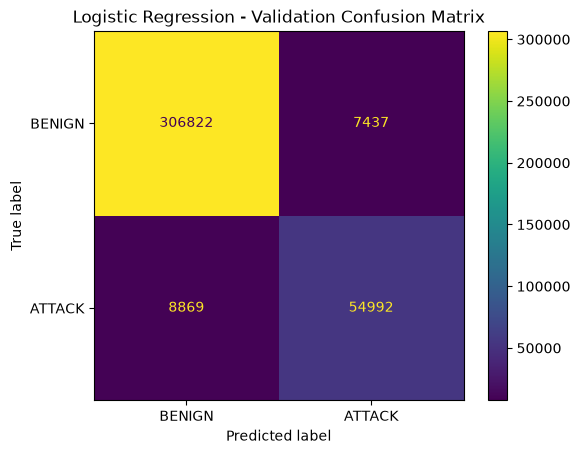

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_lr,
    display_labels=["BENIGN", "ATTACK"]
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

In [22]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [23]:
y_val_pred_rf = rf_model.predict(X_val)

y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

In [24]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_rf))

print("Precision:",
      precision_score(y_val, y_val_pred_rf))

print("Recall:",
      recall_score(y_val, y_val_pred_rf))

print("F1:",
      f1_score(y_val, y_val_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_prob_rf))

print("PR-AUC:",
      average_precision_score(y_val, y_val_prob_rf))

Accuracy: 0.9990241193271977
Precision: 0.9966986888631598
Recall: 0.9975258765130518
F1: 0.9971121111328507
ROC-AUC: 0.9999735285611641
PR-AUC: 0.9998653423277686


In [25]:
from xgboost import XGBClassifier

In [26]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [27]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
y_val_pred_xgb = xgb_model.predict(X_val)

y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

In [29]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_xgb))

print("Precision:",
      precision_score(y_val, y_val_pred_xgb))

print("Recall:",
      recall_score(y_val, y_val_pred_xgb))

print("F1:",
      f1_score(y_val, y_val_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_prob_xgb))

print("PR-AUC:",
      average_precision_score(y_val, y_val_prob_xgb))

Accuracy: 0.9991722204591135
Precision: 0.996391188876738
Recall: 0.9987159612282926
F1: 0.9975522205973207
ROC-AUC: 0.9999805422012784
PR-AUC: 0.999901205732541


## 4. Neural Network Baseline

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [ ]:
X_train_tensor = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

X_val_tensor = torch.tensor(
    X_val.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1, 1)

In [ ]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

In [ ]:
input_size = X_train.shape[1]

class IDSNeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
nn_model = IDSNeuralNetwork(input_size).to(device)

print(nn_model)

IDSNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=70, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    nn_model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = nn_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/5], Loss: 0.0679
Epoch [2/5], Loss: 0.0387
Epoch [3/5], Loss: 0.0345
Epoch [4/5], Loss: 0.0319
Epoch [5/5], Loss: 0.0309


In [ ]:
nn_model.eval()

with torch.no_grad():

    X_val_device = X_val_tensor.to(device)

    logits = nn_model(X_val_device)

    probabilities = torch.sigmoid(logits)

    y_val_prob_nn = probabilities.cpu().numpy().ravel()

    y_val_pred_nn = (
        y_val_prob_nn >= 0.5
    ).astype(int)

In [ ]:
print("Neural Network")

print(
    "Accuracy:",
    accuracy_score(y_val, y_val_pred_nn)
)

print(
    "Precision:",
    precision_score(y_val, y_val_pred_nn)
)

print(
    "Recall:",
    recall_score(y_val, y_val_pred_nn)
)

print(
    "F1:",
    f1_score(y_val, y_val_pred_nn)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_val, y_val_prob_nn)
)

print(
    "PR-AUC:",
    average_precision_score(y_val, y_val_prob_nn)
)

Neural Network
Accuracy: 0.9836797841954935
Precision: 0.9600771979073625
Recall: 0.9425627534802148
F1: 0.9512393625006914
ROC-AUC: 0.9987056891375631
PR-AUC: 0.9940012470167873


In [ ]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

torch.save(
    nn_model.state_dict(),
    MODEL_DIR / "neural_network_baseline.pth"
)

print("Neural network saved.")

Neural network saved.


In [32]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [33]:
import joblib

joblib.dump(
    lr_model,
    MODEL_DIR / "logistic_regression.pkl"
)

['models\\logistic_regression.pkl']

In [34]:
joblib.dump(
    lr_model,
    MODEL_DIR / "logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest.pkl"
)

joblib.dump(
    xgb_model,
    MODEL_DIR / "xgboost.pkl"
)

print("Classical models saved.")

Classical models saved.
